# Exercise: Bike Share Analysis

This notebook gives you practice using Pandas on a messier, more realistic dataset. You'll work with February 2014 trip data from a bike share scheme, cleaning column names, exploring patterns, filtering, grouping, and creating visualisations. A good data scientist doesn't always invent solutions from scratch; knowing where to look and how to adapt existing code is a core skill. If you get stuck, [Sebastian Raschka's Pandas tips](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb) and the [Pandas documentation](https://pandas.pydata.org/docs/) are excellent references.

---

<center><img src="../assets/nextbike_bike_rental_berlin.jpg" width="800"/></center>

In [1]:
# --- Starter code: run this cell first ---
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/bike_share_201402_trip_data.csv")
df.head()

,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscription Type,Zip Code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


## Part 1: Cleaning and Exploring

### Challenge 1: How many trips are in the dataset?

Find the number of observations (rows) in the DataFrame.

In [2]:
# Number of trips (rows)
len(df)

144015

### Challenge 2: Make the column names Pythonic

Rename all columns so they are:
- **Lowercase**
- Spaces replaced with `_`
- `#` replaced with `num`

Print the updated column names to verify.

In [3]:
# Normalize column names: lowercase, spaces to underscores, and # to num
df.columns = (
    df.columns.str.lower()
    .str.replace("#", "num", regex=False)
    .str.replace(r"\s+", "_", regex=True)
)
print(df.columns.tolist())

['trip_id', 'duration', 'start_date', 'start_station', 'start_terminal', 'end_date', 'end_station', 'end_terminal', 'bike_num', 'subscription_type', 'zip_code']


---

## Part 2: Subscription Analysis

### Challenge 3: Subscription types

How many types of subscription are there? What are they?

In [4]:
# Distinct subscription types
subscription_types = df["subscription_type"].unique()
print(f"Number of subscription types: {len(subscription_types)}")
subscription_types

Number of subscription types: 2


<StringArray>
['Subscriber', 'Customer']
Length: 2, dtype: str

### Challenge 4: Frequency of each subscription type

How many trips were made by each subscription type?

In [5]:
# Trips made by each subscription type
subscription_counts = df["subscription_type"].value_counts()
subscription_counts

subscription_type
Subscriber    113647
Customer       30368
Name: count, dtype: int64

### Challenge 5: Visualise subscription frequency, pie chart

Plot the frequency of each subscription type as a pie chart.

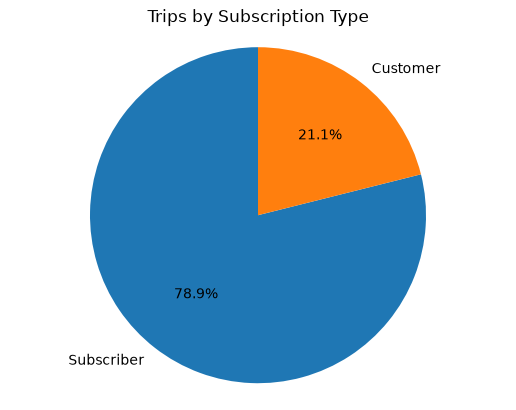

In [6]:
# Share of trips by subscription type
subscription_counts.plot(
    kind="pie",
    autopct="%.1f%%",
    startangle=90,
    ylabel="",
    title="Trips by Subscription Type",
)
plt.axis("equal")
plt.show()

### Challenge 6: Visualise subscription frequency, bar chart

Plot the same data as a bar chart.

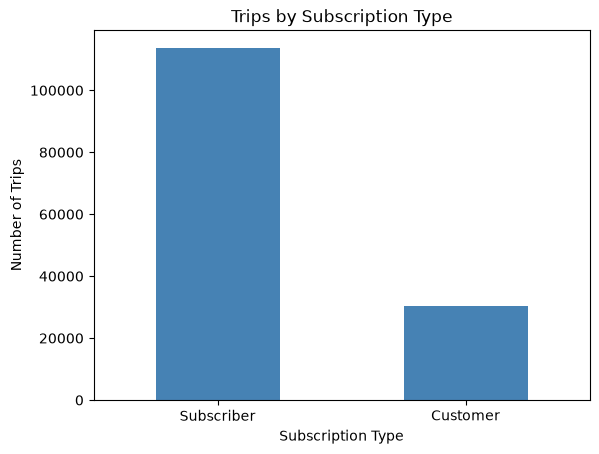

In [7]:
# Trips by subscription type as a bar chart
subscription_counts.plot(
    kind="bar",
    title="Trips by Subscription Type",
    color="steelblue",
    rot=0,
)
plt.xlabel("Subscription Type")
plt.ylabel("Number of Trips")
plt.show()

---

## Part 3: Station Analysis

### Challenge 7: Top 10 most popular start stations

Which 10 start stations appear most frequently in the data?

In [8]:
# Ten most frequent start stations
df["start_station"].value_counts().head(10)

start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64

### Challenge 8: 10 least popular end stations

Which 10 end stations appear least often?

In [9]:
# Ten least frequent end stations
df["end_station"].value_counts().nsmallest(10)

end_station
Mezes Park                            5
San Jose Government Center           23
Broadway at Main                     56
Franklin at Maple                    93
San Antonio Shopping Center          93
San Mateo County Center             106
Redwood City Public Library         117
Castro Street and El Camino Real    129
Redwood City Medical Center         178
Broadway St at Battery St           205
Name: count, dtype: int64

### Challenge 9: Cross-tabulation of start stations by subscription type

Create a table that shows the count of trips for each `start_station` segmented by `subscription_type`, including row and column totals (subtotals).

> Hint: look up `pd.crosstab()` in the documentation.

In [10]:
# Start-station trip counts split by subscription type, with row/column totals
station_subscription_counts = pd.crosstab(
    df["start_station"],
    df["subscription_type"],
    margins=True,
    margins_name="Total",
)
station_subscription_counts

subscription_type,Customer,Subscriber,Total
start_station,,,
2nd at Folsom,427,3349,3776
2nd at South Park,535,3923,4458
2nd at Townsend,882,4105,4987
5th at Howard,606,2029,2635
Adobe on Almaden,75,260,335
...,...,...,...
Townsend at 7th,518,3975,4493
University and Emerson,328,106,434
Washington at Kearney,561,911,1472


---

## Part 4: Trip Duration

### Challenge 10: Explore duration

What unit do you think the `duration` column uses? Find the shortest and longest trips. How many trips are as short as the minimum?

In [11]:
# Durations are recorded in seconds; inspect minimum and maximum values
shortest_duration = df["duration"].min()
longest_duration = df["duration"].max()
minimum_trip_count = int((df["duration"] == shortest_duration).sum())

print(f"Shortest trip: {shortest_duration} seconds")
print(f"Longest trip: {longest_duration} seconds ({longest_duration / 86400:.2f} days)")
print(f"Trips at the minimum duration: {minimum_trip_count}")

Shortest trip: 60 seconds
Longest trip: 722236 seconds (8.36 days)
Trips at the minimum duration: 17


### Challenge 11: Define and count "long" trips

Define what you consider a "long" trip (justify your threshold). How many trips meet that definition? What might explain the very long durations?

In [12]:
# Define a long trip as more than 30 minutes (1,800 seconds)
# This is a useful cutoff for separating short urban trips from extended rentals.
long_trip_threshold = 30 * 60
long_trip_count = int((df["duration"] > long_trip_threshold).sum())
long_trip_percentage = long_trip_count / len(df) * 100

print(f"Trips longer than 30 minutes: {long_trip_count:,} ({long_trip_percentage:.1f}%)")
print(
    "Very long durations may reflect bikes not returned promptly, extended rentals, "
    "or data-entry/device errors; the duration alone cannot distinguish these causes."
)

Trips longer than 30 minutes: 9,287 (6.4%)
Very long durations may reflect bikes not returned promptly, extended rentals, or data-entry/device errors; the duration alone cannot distinguish these causes.


### Challenge 12: Plot the duration distribution

Create a histogram of the `duration` column. Does it give clear insights? If not, filter to a more meaningful range and re-plot.

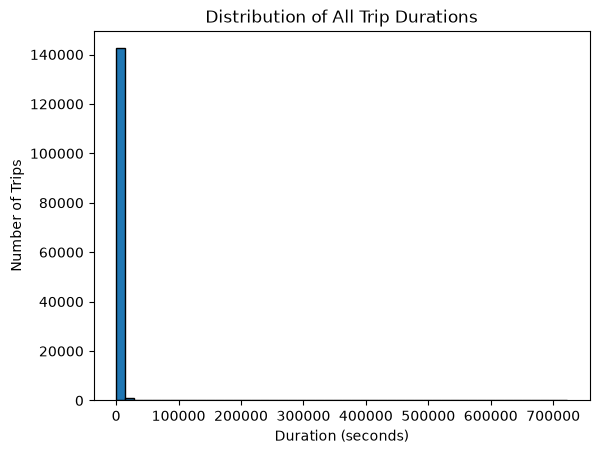

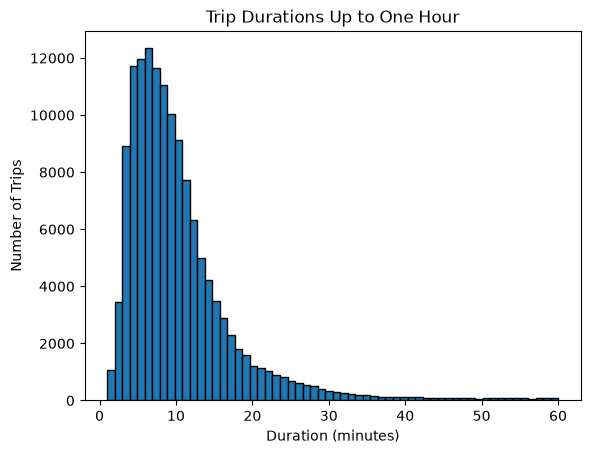

Trips within one hour: 138,320 of 144,015


In [13]:
# The full distribution has a long tail, so first plot all durations

df["duration"].plot(
    kind="hist",
    bins=50,
    title="Distribution of All Trip Durations",
    edgecolor="black",
)
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Trips")
plt.show()

# Re-plot trips up to one hour to make the typical-trip pattern easier to see
durations_under_hour = df.loc[df["duration"] <= 3600, "duration"] / 60
durations_under_hour.plot(
    kind="hist",
    bins=60,
    title="Trip Durations Up to One Hour",
    edgecolor="black",
)
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Trips")
plt.show()
print(f"Trips within one hour: {len(durations_under_hour):,} of {len(df):,}")

---

## Part 5: Data Cleaning (Advanced)

### Challenge 13: Normalise station names

The product team wants all station names to be lowercase with underscores as separators.

Example: `South Van Ness at Market` → `south_van_ness_at_market`

Apply this transformation to both the `start_station` and `end_station` columns.

> **Do NOT use a for loop.** Use a vectorised Pandas string method instead, it will be much faster.

In [14]:
# Normalize station names with vectorized string operations
df["start_station"] = (
    df["start_station"]
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)
df["end_station"] = (
    df["end_station"]
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)
df[["start_station", "end_station"]].head()

,start_station,end_station
0,south_van_ness_at_market,south_van_ness_at_market
1,san_jose_city_hall,san_jose_city_hall
2,mountain_view_city_hall,mountain_view_city_hall
3,san_jose_city_hall,san_jose_city_hall
4,south_van_ness_at_market,market_at_10th


### Challenge 14: Open-ended exploration

Set a 15-minute timer. Use that time to explore the data guided by your own curiosity or hypotheses. What patterns can you find?

> Time-boxing is a useful technique when exploring new data: it prevents you from falling into rabbit holes and forces you to prioritise the most interesting questions.

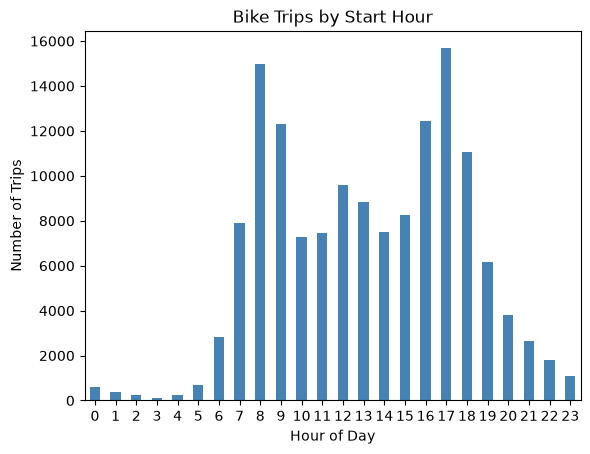

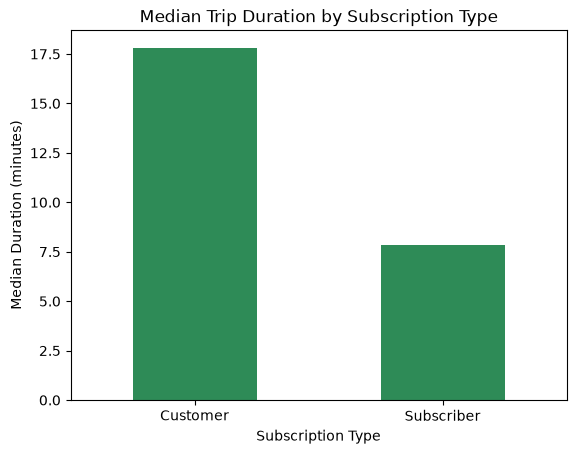

Busiest start hours:
start_date
17    15670
8     14991
16    12446
Name: count, dtype: int64
Median duration in minutes by subscription type:
subscription_type
Customer      17.8
Subscriber     7.8
Name: duration, dtype: float64


In [15]:
# Explore start-time patterns and trip duration by subscription type
df["start_date"] = pd.to_datetime(df["start_date"])
hourly_trip_counts = df["start_date"].dt.hour.value_counts().sort_index()

hourly_trip_counts.plot(
    kind="bar",
    title="Bike Trips by Start Hour",
    color="steelblue",
    rot=0,
)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

median_duration_minutes = (
    df.groupby("subscription_type")["duration"].median() / 60
)
median_duration_minutes.plot(
    kind="bar",
    title="Median Trip Duration by Subscription Type",
    color="seagreen",
    rot=0,
)
plt.xlabel("Subscription Type")
plt.ylabel("Median Duration (minutes)")
plt.show()

print("Busiest start hours:")
print(hourly_trip_counts.nlargest(3))
print("Median duration in minutes by subscription type:")
print(median_duration_minutes.round(1))